# Linear model: steady-state loss vs. step-size and distractor count

**Task.** Each step draws $x \sim \mathcal{N}(0, I_d)$ with $d = 5 + n_{\text{distractors}}$. Only the
first 5 inputs matter:

$$y = a^\top x_{1:5} + \epsilon, \qquad a_i \in \{-1, +1\}, \quad \epsilon \sim \mathcal{N}(0, 1).$$

The remaining $n_{\text{distractors}}$ inputs are i.i.d. standard normal and independent of $y$.
Every 100 steps one of the 5 coefficients (chosen uniformly at random) flips sign, so the problem
is non-stationary and no weight vector is ever permanently correct.

**Learner.** A linear model trained with LMS, $w \leftarrow w + \alpha\,\delta\,x$ where
$\delta = y - w^\top x$. Reported loss is the squared error $\delta^2$, whose floor is 1 (the
irreducible noise).

**Steady-state loss.** The flip cycle makes the instantaneous expected loss periodic, so
"steady state" means the *cycle average*: the mean loss over a whole 100-step period once the
transient has died out. Empirically this is the mean squared error over the last 500k steps of a
520k-step run; analytically it is the average of $1 + \mathbb{E}\lVert w - a\rVert^2$ over the 100
steps of the limit cycle.

In [19]:
import functools
import time

import jax
jax.config.update('jax_enable_x64', True)

import equinox as eqx
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from phd.research_utils.analysis.analysis_utils import set_matplotlib_style, save_fig_versions
from phd.research_utils.analysis.plotting import plot_param_sensitivity

set_matplotlib_style('2-row')
%matplotlib inline

N_USEFUL = 5
FLIP_PERIOD = 100
N_DISTRACTORS = [0, 4, 16, 64, 256]
STEP_SIZES = [2.0 ** -k for k in range(2, 11)]
N_SEEDS = 10
N_STEPS, N_BURNIN = 520_000, 20_000

# Sequential palette over distractor counts (same treatment as the weight-pruning scaling plots).
DISTRACTOR_PALETTE = dict(zip(
    N_DISTRACTORS,
    sns.color_palette('viridis', n_colors=len(N_DISTRACTORS)),
))

# Above this the run has effectively blown up; treat it as divergent rather than plotting it.
DIVERGENCE_CUTOFF = 1e3


def save_fig(name):
    """Save current figure as PDF and PNG (with and without legend)."""
    save_fig_versions(name, dir='../analysis/figures/pdf/', type='pdf')
    save_fig_versions(name, dir='../analysis/figures/png/', type='png')


---
## 1. Empirical steady-state loss

One `jax.lax.scan` over the 520k steps, `vmap`-ed over the 9 step-sizes x 10 seeds so a whole
distractor setting runs as a single kernel. Only the loss accumulator is carried out of the scan.

In [20]:
class LinearModel(eqx.Module):
    w: jax.Array

    def __call__(self, x):
        return self.w @ x


def squared_error(model, x, y):
    return (y - model(x)) ** 2


@functools.partial(jax.jit, static_argnums=(2, 3, 4))
def run_one(step_size, seed, n_distractors, n_steps, n_burnin):
    """Mean squared error over steps [n_burnin, n_steps) for one (step-size, seed) run."""
    d = N_USEFUL + n_distractors
    model = LinearModel(jnp.zeros(d))
    key, coef_key = jax.random.split(jax.random.fold_in(jax.random.PRNGKey(0), seed))
    init_coefs = jax.random.rademacher(coef_key, (N_USEFUL,)).astype(jnp.float64)

    def step(carry, t):
        model, coefs, key = carry
        key, flip_key, x_key, noise_key = jax.random.split(key, 4)

        # Flip one randomly chosen coefficient at the start of every period after the first.
        i = jax.random.randint(flip_key, (), 0, N_USEFUL)
        coefs = jnp.where(
            (t > 0) & (t % FLIP_PERIOD == 0), coefs.at[i].set(-coefs[i]), coefs)

        x = jax.random.normal(x_key, (d,))
        y = coefs @ x[:N_USEFUL] + jax.random.normal(noise_key, ())

        loss = squared_error(model, x, y)
        # LMS: grad of 0.5 * delta^2 is -delta * x, so this is w <- w + step_size * delta * x.
        grads = eqx.filter_grad(lambda m, x, y: 0.5 * squared_error(m, x, y))(model, x, y)
        model = eqx.apply_updates(model, jax.tree.map(lambda g: -step_size * g, grads))

        return (model, coefs, key), jnp.where(t >= n_burnin, loss, 0.0)

    _, losses = jax.lax.scan(step, (model, init_coefs, key), jnp.arange(n_steps))
    return losses.sum() / (n_steps - n_burnin)


run_grid = jax.jit(
    jax.vmap(jax.vmap(run_one, (None, 0, None, None, None)), (0, None, None, None, None)),
    static_argnums=(2, 3, 4),
)

In [21]:
rows = []
for n_dist in N_DISTRACTORS:
    t0 = time.time()
    losses = np.asarray(run_grid(
        jnp.asarray(STEP_SIZES), jnp.arange(N_SEEDS), n_dist, N_STEPS, N_BURNIN))
    print(f'{n_dist:4d} distractors: {losses.shape[0]}x{losses.shape[1]} runs in {time.time() - t0:5.1f}s')
    for lr, per_seed in zip(STEP_SIZES, losses):
        for seed, loss in enumerate(per_seed):
            rows.append({'n_distractors': n_dist, 'step_size': lr, 'seed': seed, 'loss': loss})

emp_df = pd.DataFrame(rows)
diverged = ~np.isfinite(emp_df['loss']) | (emp_df['loss'] > DIVERGENCE_CUTOFF)
emp_df.loc[diverged, 'loss'] = np.nan
print(f'\n{diverged.sum()} / {len(emp_df)} runs diverged (loss non-finite or > {DIVERGENCE_CUTOFF:g})')
emp_df.groupby(['n_distractors', 'step_size'])['loss'].mean().unstack()

   0 distractors: 9x10 runs in  10.6s
   4 distractors: 9x10 runs in  11.0s
  16 distractors: 9x10 runs in  11.7s
  64 distractors: 9x10 runs in  11.6s
 256 distractors: 9x10 runs in  12.2s

130 / 450 runs diverged (loss non-finite or > 1000)


step_size,0.000977,0.001953,0.003906,0.007812,0.015625,0.031250,0.062500,0.125000,0.250000
n_distractors,,,,,,,,,
0,5.183936,4.608496,3.832826,2.987989,2.265748,1.792245,1.607280,1.837422,6.506974
4,5.193908,4.626372,3.863081,3.036607,2.343234,1.927500,1.913045,3.301166,NaN
16,5.224755,4.681914,3.957917,3.192929,2.610878,2.491748,4.464475,NaN,NaN
64,5.351802,4.917783,4.388670,4.021498,4.809813,NaN,NaN,NaN,NaN
256,5.927267,6.158228,7.770851,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
def to_plot_frames(df):
    """Split a (n_distractors, step_size, seed, loss) frame into the run/config pair that
    `plot_param_sensitivity` expects. Each row becomes a one-step 'run'."""
    df = df.reset_index(drop=True).copy()
    df['run_id'] = df.index.astype(str)
    run_df = df[['run_id', 'loss']].assign(step=0)
    config_df = df[['run_id', 'n_distractors', 'step_size']]
    return run_df, config_df

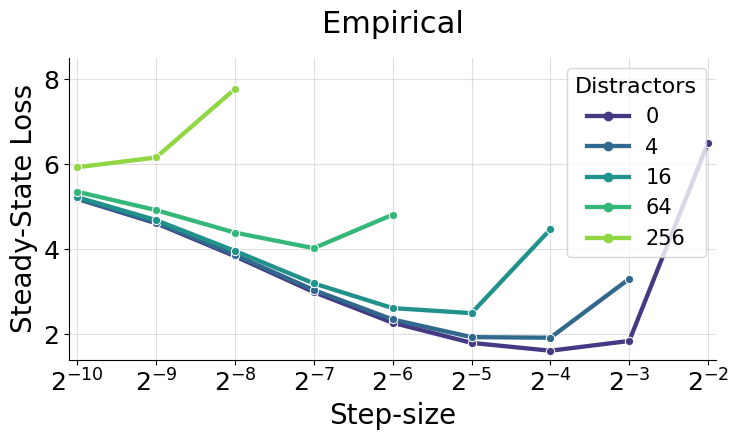

In [23]:
emp_run, emp_cfg = to_plot_frames(emp_df)

plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=emp_run, config_df=emp_cfg,
    x_col='step_size',
    title='Empirical',
    x_label='Step-size', y_label='Steady-State Loss',
    metric_col='loss', metric_type='last',
    hue_col='n_distractors', legend_title='Distractors',
    palette=DISTRACTOR_PALETTE,
    pow_2_x_axis=True, nan_policy='omit', show_ci=True,
)
plt.ylim(1.4, 8.5)
plt.tight_layout()
save_fig('linear_distractor_lr_sensitivity_empirical')
plt.show()

---
## 2. Analytic steady-state loss

Let $v = w - a$ (with $a_j = 0$ on distractor coordinates) and let $S = \operatorname{diag}(a)$ on
the useful block. Work in the sign-aligned error $p = S v$; because $Sx$ has the same distribution
as $x$, $p$ obeys the same LMS recursion as $v$, and $\lVert p\rVert = \lVert v\rVert$. The
instantaneous expected loss is

$$\mathbb{E}[\delta^2] = 1 + \mathbb{E}\lVert p \rVert^2 .$$

**Between flips.** With $p \perp x$ and $x \sim \mathcal{N}(0, I_d)$, Isserlis' theorem gives
$\mathbb{E}[xx^\top M xx^\top] = 2M + \operatorname{tr}(M) I$, so $M = \mathbb{E}[pp^\top]$ evolves as

$$M \leftarrow (1 - 2\alpha + 2\alpha^2)\,M + \alpha^2\big(\operatorname{tr} M + 1\big) I,
\qquad \mathbb{E}[p] \leftarrow (1 - \alpha)\,\mathbb{E}[p].$$

**At a flip.** Flipping $a_i$ sends $v_i \mapsto v_i + 2a_i$ and $a_i \mapsto -a_i$, hence
$p_i \mapsto -p_i - 2$: it inverts the sign-aligned error and adds a fixed offset of 2. Averaging
over the uniformly chosen index, the per-useful-coordinate mean $\mu$ and second moment $q$ go to

$$\mu \leftarrow \tfrac{3}{5}\mu - \tfrac{2}{5}, \qquad q \leftarrow q + \tfrac{4}{5}\mu + \tfrac{4}{5}.$$

Both maps are affine in $(\mu, q, r)$ — $r$ being the distractor second moment — and the off-diagonals
of $M$ never enter the loss, so the whole 100-step cycle is a $4\times 4$ affine map (the 4th
coordinate carries the constant). Solving its fixed point and averaging $1 + 5q + n_d\, r$ over the
cycle gives the exact steady-state loss. The recursion diverges iff
$\rho = 1 - 2\alpha + \alpha^2(d + 2) \ge 1$, i.e. $\alpha \ge 2 / (d + 2)$.

In [24]:
def _between_flip_map(step_size, n_distractors):
    """One LMS step as an affine map on (mu, q, r, 1)."""
    a, a2 = step_size, step_size ** 2
    decay = 1 - 2 * a + 2 * a2
    A = np.zeros((4, 4))
    A[3, 3] = 1.0
    A[0, 0] = 1 - a
    A[1, 1], A[1, 2], A[1, 3] = decay + N_USEFUL * a2, n_distractors * a2, a2
    A[2, 1], A[2, 2], A[2, 3] = N_USEFUL * a2, decay + n_distractors * a2, a2
    return A


def _flip_map():
    """A sign flip on one of the N_USEFUL coefficients, averaged over which one."""
    F = np.eye(4)
    F[0, 0], F[0, 3] = 1 - 2 / N_USEFUL, -2 / N_USEFUL
    F[1, 0], F[1, 3] = 4 / N_USEFUL, 4 / N_USEFUL
    return F


def analytic_loss(step_size, n_distractors):
    """Cycle-averaged steady-state loss; inf when the LMS recursion is unstable."""
    d = N_USEFUL + n_distractors
    if 1 - 2 * step_size + step_size ** 2 * (d + 2) >= 1:
        return np.inf

    A = _between_flip_map(step_size, n_distractors)
    powers = [np.eye(4)]
    for _ in range(FLIP_PERIOD):
        powers.append(A @ powers[-1])

    # Steady state at the start of a cycle: s = F @ A^100 @ s, with s[3] pinned to 1.
    cycle = _flip_map() @ powers[-1]
    s = np.concatenate([np.linalg.solve(np.eye(3) - cycle[:3, :3], cycle[:3, 3]), [1.0]])

    states = np.stack([P @ s for P in powers[:FLIP_PERIOD]])
    return float(np.mean(1 + N_USEFUL * states[:, 1] + n_distractors * states[:, 2]))

In [25]:
ana_df = pd.DataFrame([
    {'n_distractors': n_dist, 'step_size': lr, 'seed': 0, 'loss': analytic_loss(lr, n_dist)}
    for n_dist in N_DISTRACTORS for lr in STEP_SIZES
])
ana_df.loc[~np.isfinite(ana_df['loss']), 'loss'] = np.nan
ana_df.groupby(['n_distractors', 'step_size'])['loss'].mean().unstack()

step_size,0.000977,0.001953,0.003906,0.007812,0.015625,0.031250,0.062500,0.125000,0.250000
n_distractors,,,,,,,,,
0,5.198726,4.619444,3.838749,2.990297,2.267328,1.793992,1.609342,1.840,6.64
4,5.208935,4.637684,3.869398,3.039119,2.344843,1.929388,1.915883,3.312,NaN
16,5.239803,4.693281,3.964353,3.195640,2.612825,2.494086,4.470394,NaN,NaN
64,5.367021,4.929668,4.395847,4.024779,4.813099,NaN,NaN,NaN,NaN
256,5.944314,6.173422,7.785415,NaN,NaN,NaN,NaN,NaN,NaN


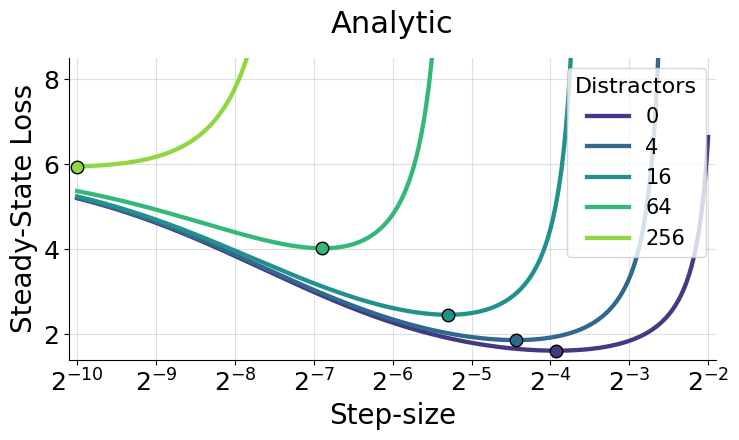

In [26]:
# The analytic form is defined for every step-size, so sweep it densely rather than only at
# the 9 powers of 2 used empirically. Each curve runs off the top of the axes at its stability
# boundary, alpha = 2 / (d + 2), where the steady-state loss diverges.
DENSE_STEP_SIZES = 2.0 ** np.linspace(-10, -2, 500)

plt.figure(figsize=(7.5, 4.5))
for n_dist in N_DISTRACTORS:
    curve = np.array([analytic_loss(lr, n_dist) for lr in DENSE_STEP_SIZES])
    plt.plot(np.log2(DENSE_STEP_SIZES), curve,
             color=DISTRACTOR_PALETTE[n_dist], label=n_dist)
    best = np.nanargmin(np.where(np.isfinite(curve), curve, np.nan))
    plt.plot(np.log2(DENSE_STEP_SIZES[best]), curve[best], 'o',
             color=DISTRACTOR_PALETTE[n_dist], markersize=9,
             markeredgecolor='black', markeredgewidth=1.0, zorder=5)

exponents = np.arange(-10, -1)
plt.xticks(exponents, [f'$2^{{{e}}}$' for e in exponents])
plt.xlim(exponents[0] - 0.1, exponents[-1] + 0.1)
plt.ylim(1.4, 8.5)
plt.grid(True, alpha=0.4)
plt.title('Analytic')
plt.xlabel('Step-size')
plt.ylabel('Steady-State Loss')
plt.legend(title='Distractors')
plt.tight_layout()
save_fig('linear_distractor_lr_sensitivity_analytic')
plt.show()

---
## 3. Do the numbers agree?

In [27]:
comp = (emp_df.groupby(['n_distractors', 'step_size'])['loss'].mean().rename('empirical')
        .to_frame()
        .join(ana_df.set_index(['n_distractors', 'step_size'])['loss'].rename('analytic')))
comp['rel_err'] = (comp['empirical'] - comp['analytic']).abs() / comp['analytic']

both = comp.dropna()
print(f'{len(both)} settings where both converged; '
      f'median |rel err| = {both["rel_err"].median():.4%}, max = {both["rel_err"].max():.4%}')
print('Divergence agrees everywhere:',
      bool((comp['empirical'].isna() == comp['analytic'].isna()).all()))
comp

32 settings where both converged; median |rel err| = 0.1583%, max = 2.0034%
Divergence agrees everywhere: True


empirical  analytic   rel_err
n_distractors step_size                               
0             0.000977    5.183936  5.198726  0.002845
              0.001953    4.608496  4.619444  0.002370
              0.003906    3.832826  3.838749  0.001543
              0.007812    2.987989  2.990297  0.000772
              0.015625    2.265748  2.267328  0.000697
              0.031250    1.792245  1.793992  0.000974
              0.062500    1.607280  1.609342  0.001281
              0.125000    1.837422  1.840000  0.001401
              0.250000    6.506974  6.640000  0.020034
4             0.000977    5.193908  5.208935  0.002885
              0.001953    4.626372  4.637684  0.002439
              0.003906    3.863081  3.869398  0.001633
              0.007812    3.036607  3.039119  0.000826
              0.015625    2.343234  2.344843  0.000686
              0.031250    1.927500  1.929388  0.000978
              0.062500    1.913045  1.915883  0.001481
              0.125000    3.301166  3.312000  0.003271
              0.250000         NaN       NaN       NaN
16            0.000977    5.224755  5.239803  0.002872
              0.001953    4.681914  4.693281  0.002422
              0.003906    3.957917  3.964353  0.001623
              0.007812    3.192929  3.195640  0.000848
              0.015625    2.610878  2.612825  0.000745
              0.031250    2.491748  2.494086  0.000937
              0.062500    4.464475  4.470394  0.001324
              0.125000         NaN       NaN       NaN
              0.250000         NaN       NaN       NaN
64            0.000977    5.351802  5.367021  0.002836
              0.001953    4.917783  4.929668  0.002411
              0.003906    4.388670  4.395847  0.001633
              0.007812    4.021498  4.024779  0.000815
              0.015625    4.809813  4.813099  0.000683
              0.031250         NaN       NaN       NaN
              0.062500         NaN       NaN       NaN
              0.125000         NaN       NaN       NaN
              0.250000         NaN       NaN       NaN
256           0.000977    5.927267  5.944314  0.002868
              0.001953    6.158228  6.173422  0.002461
              0.003906    7.770851  7.785415  0.001871
              0.007812         NaN       NaN       NaN
              0.015625         NaN       NaN       NaN
              0.031250         NaN       NaN       NaN
              0.062500         NaN       NaN       NaN
              0.125000         NaN       NaN       NaN
              0.250000         NaN       NaN       NaN